# Introduction to Plotting with Python and Matplotlib

---

One of Python's most powerful features is its ability to create high-quality figures for data analysis. The library that handles this is called **matplotlib** — and it's what professional scientists, engineers, and data analysts use every day.

In this tutorial, you'll learn how to:

1. Create a basic line plot from a pandas DataFrame
2. Add a title to your figure
3. Label the x and y axes (with units!)
4. Change the color, style, and thickness of lines
5. Add a legend when plotting multiple lines
6. Save your figure as an image file

No prior experience with Python or matplotlib is needed. Each section builds on the last, and every new concept is explained before you use it.

---

### How to use this notebook

- **Code cells** (gray boxes) contain Python code. Click on one and press `Shift + Enter` to run it.
- **Text cells** (like this one) contain explanations and instructions.
- Work from **top to bottom** — later cells depend on earlier ones being run first.
- If something goes wrong, you can restart and re-run everything from the top via **Kernel → Restart & Run All**.

---

## Part 1 – Setup: importing libraries and creating some data

### Importing libraries

Before we can plot anything, we need to load the tools we'll use. In Python, this is done with the `import` statement.

We'll import three things:

| What we import | Why |
|---|---|
| `pandas` (as `pd`) | Organizes data into tables called DataFrames |
| `matplotlib.pyplot` (as `plt`) | The main plotting interface |
| `numpy` (as `np`) | Math functions and tools for generating data |

The `as pd`, `as plt`, and `as np` parts are just **shorthand nicknames** — they save typing later. These abbreviations are universal conventions; you'll see them in virtually every Python data science tutorial.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# This magic command tells Jupyter to display plots directly in the notebook
%matplotlib inline

print("Libraries loaded!")

Libraries loaded!


### Creating a sample dataset

To practice plotting, we need some data. In your course assignments, data will come from files (like Excel spreadsheets). Here, we'll **create a small dataset from scratch** so we have something to work with.

We'll simulate a simple scenario: hourly air temperature measurements over the course of one day (24 hours).

We use `np.arange(0, 25)` to generate a sequence of numbers from 0 to 24. The second argument (25) is one past where we want to stop — this is a common Python convention.

Then we put both columns into a **pandas DataFrame** using a Python **dictionary** (the `{ }` curly-brace syntax). Each key (`'Hour'`, `'Temperature_C'`) becomes a column name, and each value is the list of data for that column.

In [2]:
# Create a sequence of hours: 0, 1, 2, ..., 24
hours = np.arange(0, 25)

# A realistic daily temperature curve:
# coolest around 5–6 AM, warmest around 2–3 PM
# We use a cosine function to mimic this shape
temperature = 15 - 8 * np.cos(2 * np.pi * (hours - 14) / 24)

# Package both into a DataFrame
df = pd.DataFrame({
    'Hour': hours,
    'Temperature_C': temperature
})

# Preview the data
print(f"Dataset has {len(df)} rows and {len(df.columns)} columns.")
df.head(8)

Dataset has 25 rows and 2 columns.


,Hour,Temperature_C
0,0,21.928203
1,1,22.727407
2,2,23.000000
3,3,22.727407
4,4,21.928203
5,5,20.656854
6,6,19.000000
7,7,17.070552


You should see a table with 25 rows (one per hour) and two columns. The temperature values represent a typical warm day — cool in the early morning, peaking in the afternoon.

---

## Part 2 – Your first plot

### Understanding the Figure / Axes structure

Before writing any code, it's worth understanding how matplotlib thinks about a plot:

- A **Figure** (`fig`) is the entire window or image — the blank canvas.
- An **Axes** (`ax`) is the actual plot area inside the figure — the region with the data, tick marks, and labels.

A single figure can contain multiple axes (e.g., a 2×2 grid of subplots), but for now we'll always have exactly one.

```
┌────────────────────────────┐
│  Figure (fig)              │
│  ┌──────────────────────┐  │
│  │  Axes (ax)           │  │
│  │   (your actual plot) │  │
│  └──────────────────────┘  │
└────────────────────────────┘
```

We create both at once with:

```python
fig, ax = plt.subplots()
```

Everything we add to the plot — lines, labels, titles — will be attached to `ax`.

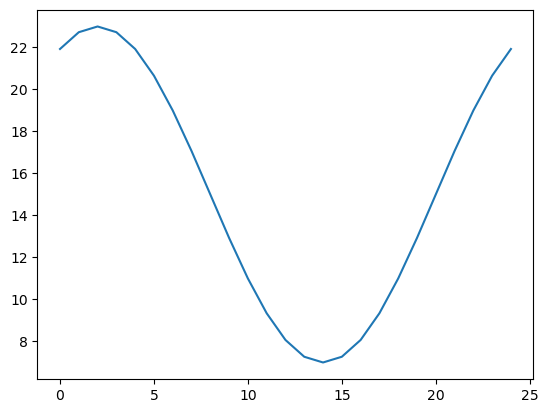

In [3]:
# Step 1: Create the figure and axes
fig, ax = plt.subplots()

# Step 2: Plot the data
# ax.plot(x_data, y_data)
ax.plot(df['Hour'], df['Temperature_C'])

# Step 3: Display the figure
plt.show()

You should see a line plot showing temperature rising through the day and peaking in the afternoon. It works — but it's not very informative yet. Someone looking at this figure would have no idea what the axes represent or what the data is.

We'll fix that in the next sections.

---

## Part 3 – Adding a title and axis labels

A figure without labels is incomplete. **Always** include:
- A **title** that describes what the figure shows
- An **x-axis label** with units
- A **y-axis label** with units

In matplotlib, we do this with three methods on our `ax` object:

| Method | What it does |
|---|---|
| `ax.set_title('...')` | Adds a title above the plot |
| `ax.set_xlabel('...')` | Labels the x (horizontal) axis |
| `ax.set_ylabel('...')` | Labels the y (vertical) axis |

Each takes a **string** (text in quotes) as its argument. It's good practice to include the **unit** in the label, e.g. `'Temperature (°C)'`.

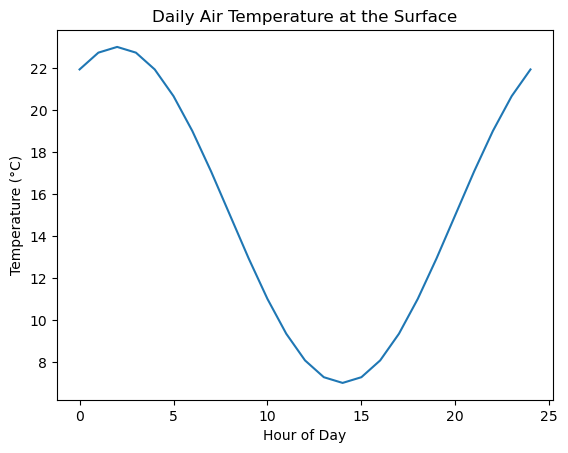

In [4]:
fig, ax = plt.subplots()

ax.plot(df['Hour'], df['Temperature_C'])

# Add a title
ax.set_title('Daily Air Temperature at the Surface')

# Label the axes — always include units!
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Temperature (°C)')

plt.show()

Much better! The figure now clearly communicates what it shows. 

### Adjusting font size

By default, the text can be a little small. You can increase the size of any label by passing a `fontsize` argument:

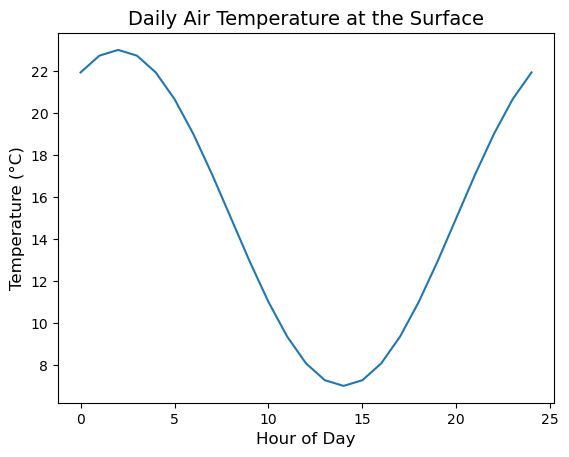

In [5]:
fig, ax = plt.subplots()

ax.plot(df['Hour'], df['Temperature_C'])

# fontsize controls how large the text appears
ax.set_title('Daily Air Temperature at the Surface', fontsize=14)
ax.set_xlabel('Hour of Day',                         fontsize=12)
ax.set_ylabel('Temperature (°C)',                    fontsize=12)

plt.show()

---

## Part 4 – Controlling line appearance

The default blue line is fine, but matplotlib gives you a lot of control over how your lines look. This is useful when you want to distinguish between multiple lines on the same plot, or match a specific style.

All of these options are passed as **keyword arguments** directly inside `ax.plot()`:

| Argument | Controls | Example values |
|---|---|---|
| `color` | Line color | `'red'`, `'steelblue'`, `'#2ca02c'` |
| `linewidth` (or `lw`) | Thickness of the line | `1.0`, `2.5`, `0.5` |
| `linestyle` (or `ls`) | Dash pattern | `'-'`, `'--'`, `':'`, `'-.'` |
| `marker` | Symbol at each data point | `'o'`, `'s'`, `'^'`, `'.'` |
| `markersize` (or `ms`) | Size of the markers | `4`, `8`, `10` |

### Specifying colors

There are several ways to specify a color in matplotlib:

- **Named colors**: `'red'`, `'blue'`, `'green'`, `'black'`, `'gray'`, `'orange'`, `'purple'`
- **CSS named colors**: `'steelblue'`, `'tomato'`, `'goldenrod'`, `'forestgreen'`
- **Hex codes**: `'#1f77b4'` (the default blue), `'#d62728'` (a nice red)

Let's experiment:

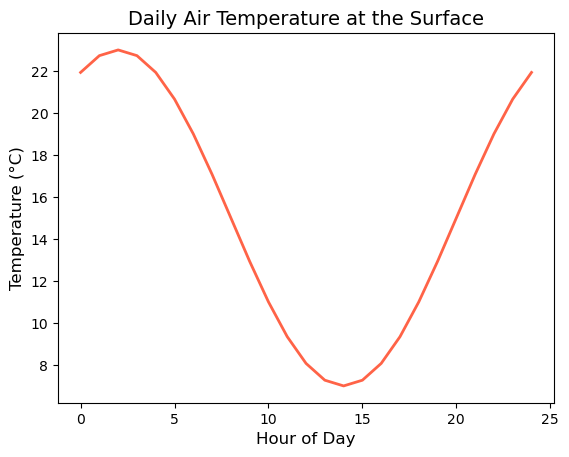

In [6]:
fig, ax = plt.subplots()

# color='tomato'   → a warm red
# linewidth=2.0    → slightly thicker than the default (1.0)
ax.plot(df['Hour'], df['Temperature_C'],
        color='tomato',
        linewidth=2.0)

ax.set_title('Daily Air Temperature at the Surface', fontsize=14)
ax.set_xlabel('Hour of Day',                         fontsize=12)
ax.set_ylabel('Temperature (°C)',                    fontsize=12)

plt.show()

### Try it yourself

Modify the cell below by changing the `color`, `linewidth`, and `linestyle` to something different. Some ideas:
- `color='forestgreen'` with `linestyle='--'` (dashed)
- `color='#5B2C6F'` (a purple hex code) with `linewidth=3`
- `color='black'` with `linestyle=':'` (dotted) and `marker='o'`

In [ ]:
fig, ax = plt.subplots()

# TODO: Change the color, linewidth, and linestyle to your own choices
ax.plot(df['Hour'], df['Temperature_C'],
        color='___',        # <-- try a different color
        linewidth=___,      # <-- try a different thickness (e.g. 1.5)
        linestyle='___')    # <-- try '-', '--', ':', or '-.'

ax.set_title('Daily Air Temperature at the Surface', fontsize=14)
ax.set_xlabel('Hour of Day',                         fontsize=12)
ax.set_ylabel('Temperature (°C)',                    fontsize=12)

plt.show()

---

## Part 5 – Plotting multiple lines and adding a legend

Often you'll want to compare two or more datasets on the same figure — for example, temperature at two different heights, or measurements from two different days.

To add a second line, simply call `ax.plot()` a second time before calling `plt.show()`. Each call adds another line to the same axes.

When you have multiple lines, you need a **legend** so readers can tell them apart. The workflow is:
1. Add a `label='...'` string inside each `ax.plot()` call
2. Call `ax.legend()` once at the end to render the legend box

We'll add a second temperature curve representing a warmer day for comparison.

In [ ]:
# A second temperature dataset — a warmer day, with a slightly different shape
temperature_warm = 22 - 9 * np.cos(2 * np.pi * (hours - 15) / 24)

fig, ax = plt.subplots()

# First line: the original dataset
# label='...' is what will appear in the legend
ax.plot(df['Hour'], df['Temperature_C'],
        color='steelblue',
        linewidth=2.0,
        label='Typical day')

# Second line: the warmer day
ax.plot(hours, temperature_warm,
        color='tomato',
        linewidth=2.0,
        label='Warm day')

ax.set_title('Daily Air Temperature Comparison', fontsize=14)
ax.set_xlabel('Hour of Day',                     fontsize=12)
ax.set_ylabel('Temperature (°C)',                fontsize=12)

# Add a legend — matplotlib automatically uses the 'label' strings from ax.plot()
ax.legend(fontsize=11)

plt.show()

Notice how each `ax.plot()` call adds one entry to the legend, using the string you provided in `label=`. If you forget to add `label=` to a line, it won't appear in the legend.

### Controlling legend placement

By default, matplotlib tries to find a good location for the legend automatically. You can override this with the `loc` argument:

In [ ]:
fig, ax = plt.subplots()

ax.plot(df['Hour'], df['Temperature_C'], color='steelblue', linewidth=2.0, label='Typical day')
ax.plot(hours, temperature_warm,         color='tomato',    linewidth=2.0, label='Warm day')

ax.set_title('Daily Air Temperature Comparison', fontsize=14)
ax.set_xlabel('Hour of Day',                     fontsize=12)
ax.set_ylabel('Temperature (°C)',                fontsize=12)

# Common loc values: 'best', 'upper left', 'upper right', 'lower left', 'lower right'
ax.legend(fontsize=11, loc='upper left')

plt.show()

---

## Part 6 – Figure size and layout

The default figure size is fairly small. For presentations or reports, you'll often want a wider or taller figure.

You control the size by passing `figsize=(width, height)` to `plt.subplots()`. The dimensions are in **inches**.

A few common sizes:
- `figsize=(8, 4)` — wide and short (good for time series)
- `figsize=(6, 6)` — square (good for scatter plots)
- `figsize=(10, 5)` — presentation-friendly widescreen

We also introduce `plt.tight_layout()` here — it automatically adjusts the spacing so that labels don't get cut off at the edges of the figure.

In [ ]:
# figsize=(width, height) in inches
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(df['Hour'], df['Temperature_C'], color='steelblue', linewidth=2.0, label='Typical day')
ax.plot(hours, temperature_warm,         color='tomato',    linewidth=2.0, label='Warm day')

ax.set_title('Daily Air Temperature Comparison', fontsize=14)
ax.set_xlabel('Hour of Day',                     fontsize=12)
ax.set_ylabel('Temperature (°C)',                fontsize=12)
ax.legend(fontsize=11)

# Automatically adjust spacing to prevent labels from being clipped
plt.tight_layout()
plt.show()

---

## Part 7 – Saving your figure to a file

When you write a report, you'll need to export your figures as image files to include them. matplotlib makes this easy with `plt.savefig()`.

```python
plt.savefig('my_figure.png', dpi=150, bbox_inches='tight')
```

- The first argument is the **filename** (including extension). The extension determines the format.
- `dpi` = **dots per inch** — controls the resolution. `150` is good for screen/web; `300` is standard for print/publication.
- `bbox_inches='tight'` trims extra whitespace around the figure edges.

**Important:** `plt.savefig()` must come **before** `plt.show()`. Once `plt.show()` is called, the figure is cleared from memory.

Common file formats:
- `.png` — lossless, great for most purposes
- `.pdf` — vector format, scales perfectly for publications
- `.jpg` — smaller file size, slight quality loss

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(df['Hour'], df['Temperature_C'], color='steelblue', linewidth=2.0, label='Typical day')
ax.plot(hours, temperature_warm,         color='tomato',    linewidth=2.0, label='Warm day')

ax.set_title('Daily Air Temperature Comparison', fontsize=14)
ax.set_xlabel('Hour of Day',                     fontsize=12)
ax.set_ylabel('Temperature (°C)',                fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()

# Save BEFORE plt.show() — order matters!
plt.savefig('temperature_comparison.png', dpi=150, bbox_inches='tight')
print("Figure saved as 'temperature_comparison.png'")

plt.show()

After running the cell, check the folder where this notebook is saved — you should see a new file called `temperature_comparison.png`.

---

## Part 8 – Putting it all together

Here's a complete, polished example that uses everything covered in this tutorial. Read through it carefully and make sure you understand each line before moving on.

Then, in the empty cell below it, try building your own figure from scratch.

In [ ]:
# ── Complete example: a polished two-line figure ──────────────────────────────

# 1. Create figure and axes (wide format)
fig, ax = plt.subplots(figsize=(10, 4))

# 2. Plot line 1 — typical day
ax.plot(
    df['Hour'],           # x data: hour of day
    df['Temperature_C'],  # y data: temperature
    color='steelblue',    # line color
    linewidth=2.0,        # line thickness
    linestyle='-',        # solid line
    marker='o',           # circle marker at each data point
    markersize=4,         # small markers
    label='Typical day'   # legend label
)

# 3. Plot line 2 — warm day
ax.plot(
    hours,
    temperature_warm,
    color='tomato',
    linewidth=2.0,
    linestyle='--',       # dashed line to visually distinguish it
    marker='s',           # square markers
    markersize=4,
    label='Warm day'
)

# 4. Title and axis labels (always include units!)
ax.set_title('Hourly Surface Air Temperature – Two-Day Comparison', fontsize=14)
ax.set_xlabel('Hour of Day (UTC)',  fontsize=12)
ax.set_ylabel('Temperature (°C)',   fontsize=12)

# 5. Legend
ax.legend(fontsize=11, loc='upper left')

# 6. Clean up spacing
plt.tight_layout()

# 7. Save and display
plt.savefig('final_temperature_plot.png', dpi=150, bbox_inches='tight')
plt.show()

### 🏁 Your turn — build a figure from scratch

The cell below is empty. Using only what you've learned in this tutorial, create a figure that:

- Plots **at least one line** using data from `df` (or any data you like)
- Has a **title**
- Has **labeled x and y axes** with units
- Uses a **color other than the default blue**
- Has a **legend** (if you plot more than one line)

You don't need to create new data — you can reuse `df['Hour']` and `df['Temperature_C']` from earlier. Focus on getting the formatting right.

In [ ]:
# Your figure here — build it from scratch!



---

## Quick Reference Card

Use this as a cheat sheet when building figures in future assignments.

```python
import matplotlib.pyplot as plt

# Create figure
fig, ax = plt.subplots(figsize=(10, 4))

# Plot a line
ax.plot(x, y,
        color='steelblue',   # line color
        linewidth=2.0,       # line thickness
        linestyle='-',       # '-'  '--'  ':'  '-.'
        marker='o',          # 'o'  's'  '^'  '.'  (optional)
        markersize=4,        # marker size (optional)
        label='My data')     # legend label

# Labels and title
ax.set_title('Title',       fontsize=14)
ax.set_xlabel('X label',    fontsize=12)
ax.set_ylabel('Y label',    fontsize=12)

# Legend (only needed if label= was used in ax.plot)
ax.legend(fontsize=11, loc='best')

# Finish
plt.tight_layout()
plt.savefig('output.png', dpi=150, bbox_inches='tight')  # optional
plt.show()
```

### Common named colors

| Color name | Appearance |
|---|---|
| `'steelblue'` | muted blue |
| `'tomato'` | warm red |
| `'forestgreen'` | dark green |
| `'goldenrod'` | golden yellow |
| `'mediumpurple'` | soft purple |
| `'darkorange'` | bright orange |
| `'black'` | black |
| `'gray'` | gray |

A full list of named colors is available at: https://matplotlib.org/stable/gallery/color/named_colors.html